In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [13]:
df = pd.read_csv('../data/q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [14]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

### Why Scaling is Important

K-Means clustering is based on distance calculations. Features with larger values can dominate the distance metric and bias the clustering results. Scaling ensures that all features contribute equally, improving clustering performance.

In [15]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

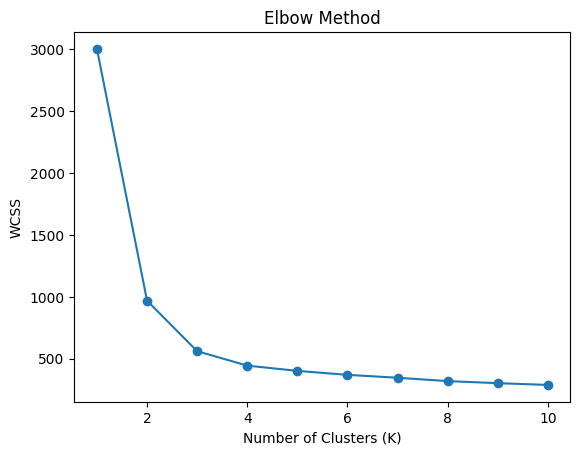

In [16]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

### Interpretation

The elbow point is where the rate of decrease in WCSS slows down significantly. This point represents the optimal number of clusters. Based on the plot, the optimal K is likely around 3 or 4, where the curve starts to flatten.

In [17]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_data)

df['cluster'] = clusters

In [18]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

Cluster 0 represents customers with lower spending and fewer visits, indicating low engagement.

Cluster 1 represents frequent visitors with moderate spending, suggesting regular customers.

Cluster 2 represents high-spending customers with frequent visits, indicating premium or loyal customers.

In [19]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [20]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [21]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

PC1 captures the direction of maximum variance in the data, often influenced by spending and visit frequency.

PC2 captures the second most important variation, possibly related to customer recency and diversity of purchases.

The loadings indicate how strongly each feature contributes to the principal components.

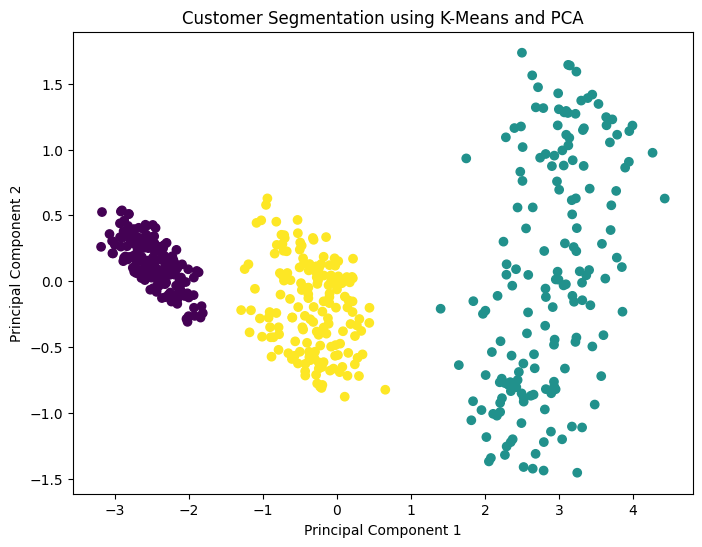

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means and PCA")

plt.show()